# Module 4 · Project — Knowledge Assistant v1 · SOLUTION

**From 0 to Agentic AI — DataHack Summit 2026**

🧩 **The build begins for real.** We assemble the **Knowledge Assistant** as an explicit
**LangGraph `StateGraph`** — the same reason→act→observe loop from Module 3, but now with
state, routing, and looping as first-class parts we control.

> ✅ **Solution notebook** — full implementations shown.

### What you'll build
1. A **State** that carries the message history
2. A **model node** that calls the LLM (with tools bound)
3. A **tool node** that runs any tool the model requested
4. A **conditional edge** — tools? loop back : finish
5. `compile()`, visualize, and **run** the assistant

---
## Setup

In [1]:
# Install the workshop stack (Colab). Locally, use `uv sync` instead.
# Version ranges match src/pyproject.toml (the single source of truth).
!pip install -q "langchain>=1.2,<2" "langchain-openai>=1.1,<2" \
               "langgraph>=1.0,<2" "langchain-tavily>=0.2"

ERROR: Could not find a version that satisfies the requirement langchain<2,>=1.2 (from versions: 0.0.1, 0.0.2, 0.0.3, 0.0.4, 0.0.5, 0.0.6, 0.0.7, 0.0.8, 0.0.9, 0.0.10, 0.0.11, 0.0.12, 0.0.13, 0.0.14, 0.0.15, 0.0.16, 0.0.17, 0.0.18, 0.0.19, 0.0.20, 0.0.21, 0.0.22, 0.0.23, 0.0.24, 0.0.25, 0.0.26, 0.0.27, 0.0.28, 0.0.29, 0.0.30, 0.0.31, 0.0.32, 0.0.33, 0.0.34, 0.0.35, 0.0.36, 0.0.37, 0.0.38, 0.0.39, 0.0.40, 0.0.41, 0.0.42, 0.0.43, 0.0.44, 0.0.45, 0.0.46, 0.0.47, 0.0.48, 0.0.49, 0.0.50, 0.0.51, 0.0.52, 0.0.53, 0.0.54, 0.0.55, 0.0.56, 0.0.57, 0.0.58, 0.0.59, 0.0.60, 0.0.61, 0.0.63, 0.0.64, 0.0.65, 0.0.66, 0.0.67, 0.0.68, 0.0.69, 0.0.70, 0.0.71, 0.0.72, 0.0.73, 0.0.74, 0.0.75, 0.0.76, 0.0.77, 0.0.78, 0.0.79, 0.0.80, 0.0.81, 0.0.82, 0.0.83, 0.0.84, 0.0.85, 0.0.86, 0.0.87, 0.0.88, 0.0.89, 0.0.90, 0.0.91, 0.0.92, 0.0.93, 0.0.94, 0.0.95, 0.0.96, 0.0.97, 0.0.98, 0.0.99rc0, 0.0.99, 0.0.100, 0.0.101rc0, 0.0.101, 0.0.102rc0, 0.0.102, 0.0.103, 0.0.104, 0.0.105, 0.0.106, 0.0.107, 0.0.108, 0.0.109, 0.0

In [2]:
import os
from getpass import getpass

# Local: load keys from src/.env (walks up to find it). Colab: prompts for missing keys.
try:
    from dotenv import load_dotenv, find_dotenv
    load_dotenv(find_dotenv(usecwd=True))
except Exception:
    pass

for key in ["OPENAI_API_KEY"]:
    if not os.environ.get(key):
        os.environ[key] = getpass(f"{key}: ")

---
## Step 1 · Tools

Our assistant starts with two tools (same idea as Module 3): a **web search** and a small
**internal directory** lookup. Later modules add real RAG, Slack, GitHub.

In [3]:
from langchain_core.tools import tool
from langchain_tavily import TavilySearch

web_search = TavilySearch(max_results=3)

@tool
def lookup_employee(name: str) -> str:
    """Look up which team an employee works on, by first name."""
    directory = {"alessandro": "Billing", "sam": "Platform", "dana": "Data"}
    return directory.get(name.lower().strip(), "not found")

tools = [web_search, lookup_employee]

---
## Step 2 · The State

**TODO:** define the graph state. It needs a single field, `messages`, that **accumulates**
(use the `add_messages` reducer) rather than overwrites.

In [4]:
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

---
## Step 3 · The model node

Bind the tools to the LLM, then write the **agent node**: it takes the state, calls the
model on the message history, and returns the reply as a state update.

**TODO:** implement `call_model` so it returns `{"messages": [<the model reply>]}`.

In [5]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("gpt-4.1-mini", model_provider="openai", temperature=0)
llm_with_tools = llm.bind_tools(tools)

def call_model(state: State):
    reply = llm_with_tools.invoke(state["messages"])
    return {"messages": [reply]}

---
## Step 4 · The tool node

When the model requests a tool, something has to run it. LangGraph ships a prebuilt
`ToolNode` that does exactly this — give it our list of tools.

In [6]:
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools)

---
## Step 5 · The conditional edge

After the model runs, we branch: **did it request a tool?** If yes → go to the tool node;
if no → we're done.

**TODO:** implement `should_continue` to return `"tools"` when the last message has
`tool_calls`, else `"end"`.

In [7]:
def should_continue(state: State) -> str:
    last = state["messages"][-1]
    return "tools" if last.tool_calls else "end"

---
## Step 6 · Wire the graph

Now connect the pieces into the loop:
`START → agent`, then the conditional edge (`agent → tools` or `agent → END`), and
crucially **`tools → agent`** so results feed back for another round.

**TODO:** add the nodes and edges, then compile.

In [8]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
builder.add_node("agent", call_model)
builder.add_node("tools", tool_node)

builder.add_edge(START, "agent")
builder.add_conditional_edges(
    "agent", should_continue, {"tools": "tools", "end": END})
builder.add_edge("tools", "agent")   # loop back

assistant = builder.compile()

### Visualize the graph
See the loop you just built — note the edge from `tools` back to `agent`.

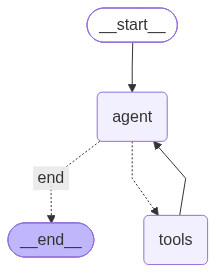

In [9]:
from IPython.display import Image, display

display(Image(assistant.get_graph().draw_mermaid_png()))

---
## Step 7 · Run it

A small helper, then three questions: one that needs the directory, one that needs web
search, and one that needs neither (the model just answers).

In [10]:
def ask(question: str):
    out = assistant.invoke({"messages": [("user", question)]})
    return out["messages"][-1].content

print(ask("What team is Dana on?"))

Dana is on the Data team.


In [11]:
print(ask("What is LangGraph, and what is its latest major version?"))

LangGraph is an open-source framework that serves as a durable agent framework for production-ready AI systems. It has been widely adopted by companies like Uber, LinkedIn, and Klarna. The latest major version of LangGraph is version 1.0, which marks its first stable major release after more than a year of iteration.

Additionally, there are more recent minor versions such as 1.2.10, but the major version milestone is 1.0.


In [12]:
print(ask("In one sentence, what is an AI agent?"))

An AI agent is a software entity that perceives its environment, processes information, and takes actions autonomously to achieve specific goals.


### Inspect the full trace
Watch the loop: agent → (tool request) → tools → agent → final answer.

In [13]:
out = assistant.invoke({"messages": [("user", "What team is Sam on?")]})
for m in out["messages"]:
    m.pretty_print()

================================ Human Message =================================

What team is Sam on?
================================== Ai Message ==================================
Tool Calls:
  lookup_employee (call_7yNMVklCBoxEAjarpViKkBGG)
 Call ID: call_7yNMVklCBoxEAjarpViKkBGG
  Args:
    name: Sam
================================= Tool Message =================================
Name: lookup_employee

Platform
================================== Ai Message ==================================

Sam is on the Platform team.


---
## Key takeaways
- The Module 3 loop is now an explicit **graph**: `agent ⇄ tools`, with a conditional exit.
- **`ToolNode`** runs requested tools; **`should_continue`** is the routing decision.
- The **`tools → agent`** edge is what makes it iterate — the loop, made visible.

➡️ **Next (Module 5):** give this assistant real, reliable tools — web search, Slack
drafts, GitHub issues — and the design principles that keep them dependable.